# Numerical Verification of Paper Statements


**Paper:** Pavel Kocourek & Eugen Kovac, *Revealing Private Information in a Patent Race*

**Purpose:** Verify all 16 numerical claims from the paper. Each statement is a property
of the equilibrium that is asserted in the text but verified numerically rather than proved
analytically. This notebook solves the ODE systems on a fine grid of discount-rate values
and checks each claim.

**Configuration:** Set `N_GRID` in the setup cell below. Use 30 for quick testing, 1000 for final verification.

**Statement index:**

| ID | Claim | Paper reference |
|----|-------|-----------------|
| S1 | $(E^{0,B}_A)'(p) < 0$ | Proposition 5 (footnote) |
| S2 | $E^{0,B}_A(p) < E^{1,B}_A(p)$ | Proposition 5 (footnote) |
| S3 | $E^{0,B}_A(p) < E^0_S(p)$ | Discussion after Proposition 8 |
| S4 | $E^{1,B}_A(p) > E^1_S(p)$ | Discussion after Proposition 8 |
| S5 | $V^{1,A}_A(p_{S,*}) < V^1_S(p_{S,*})$ for $\rho < \rho_I$ | Lemma D.1 |
| S6 | $V^{1,A}_A(0) \le V^1_S(0)$ iff $\rho \le \rho_N$ | Lemma D.2 |
| S6b | Single-crossing: if holds at $p=0$, holds for all $p \in [0, p_{S,*})$ | Lemma D.2 |
| S7 | Instant-revelation iff $\rho \ge \rho_I$ | Proposition 10 |
| S8 | $\rho_N < \rho_I$ | Proposition 12 |
| S9 | $V^{1,B}_A(p) - \overline{V}(p) > 0$ (strategic substitutes) | Proof of Lemma D.4 (SA) |
| S10 | Mixed ODE critical point is source type | Proof of Lemma D.4(ii) (SA) |
| S11 | $G_M(p)$ strictly decreasing | Proposition 11 |
| S12 | Unique crossing $\overline{p}_M \in (0, p_{S,*})$ | Lemma D.3 |
| S13 | Mixed eq doesn't exist in IR regime | Proposition 12 |
| S14 | Three equilibrium regimes | Proposition 12 |
| S15 | Deadline $T$ increases with $\rho$ | Discussion after Proposition 12 |
| S16 | Prob(revelation) increases with $\rho$ | Discussion after Proposition 12 |

In [1]:
# Install/upgrade required libraries (for Google Colab)
# numpy, scipy, matplotlib, and sympy are pre-installed on Colab,
# but we ensure compatible versions are available.
import sys
if 'google.colab' in sys.modules:
    %pip install -q numpy scipy sympy matplotlib
    print('Colab: libraries verified.')
else:
    print('Running locally — no installs needed.')


Colab: libraries verified.


In [2]:
# Setup and imports
import numpy as np
import sympy as sp
from sympy.utilities.lambdify import lambdify
from scipy.optimize import fsolve, brentq
from scipy.integrate import solve_ivp, quad, cumulative_trapezoid
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ============ CONFIGURATION ============
N_GRID = 1000    # rho grid points (production run)
N_ODE  = 1000      # ODE internal grid points
RHO_MIN = 1e-6
RHO_MAX = 10.0
# =======================================

rho_grid = np.logspace(np.log10(RHO_MIN), np.log10(RHO_MAX), N_GRID)
print(f"Grid: {N_GRID} points from {RHO_MIN} to {RHO_MAX} (rho = ar/v, normalized to r)")
print(f"Sample values: {rho_grid[0]:.2e}, ..., {rho_grid[N_GRID//2]:.4f}, ..., {rho_grid[-1]:.1f}")

Grid: 1000 points from 1e-06 to 10.0 (rho = ar/v, normalized to r)
Sample values: 1.00e-06, ..., 0.0032, ..., 10.0


In [3]:
# Define symbolic ODEs
# Three systems: symmetric (pp), asymmetric (1p), and mixed (M)
r = sp.symbols('r')

# Helper functions for labeling
prime = lambda v: sp.symbols("({" + str(v) + "})'")
dot   = lambda v: sp.symbols("\\dot{" + str(v)[0] + "}" + str(v)[1:])
SS    = lambda v: sp.symbols(str(v) + '_*')

# Symmetric model (subscript S in paper)
e1, e0, p = sp.symbols('e^1 e^0 p')
X_pp = sp.Matrix([e1, e0, p])
F_pp = sp.Matrix([
    e1**2 / 2 - (r + p * e1) * (1 - e1),
    e0**2 / 2 - e1**2 / 2 + (r + p * e1) * e0,
    (1-p) * (e0 - p * e1)
])

# Asymmetric model (subscript A in paper, one firm known to have breakthrough)
e1A, e1B, e0B, pB = sp.symbols('e^{1A} e^{1B} e^{0B} p^B')
X_1p = sp.Matrix([e1A, e1B, e0B, pB])
F_1p = sp.Matrix([
    e1A**2 / 2 - (r + pB * e1B) * (1 - e1A),
    e1B**2 / 2 - (r + e1A) * (1 - e1B),
    e0B**2 / 2 - e1B**2 / 2 + (r + e1A) * e0B,
    (1-pB) * (e0B - pB * e1B)
])

# Mixed-strategy equations
v0M, e0M, thetaM, pM = sp.symbols('v^0_M e_M^0 theta p_M')
v1A_sym, v1B_sym, v0B_sym, v1A_prime_sym = sp.symbols("v^{1A} v^{1B} v^{0B} (v^{1A})'")

pM_dot = (1-pM) * (e0M - pM * e1A - thetaM)
X_M = sp.Matrix([v0M, pM])
F_M = sp.Matrix([
    - (e0M**2 / 2 + thetaM * v0B_sym - (r + thetaM + pM * e1A) * v0M),
    pM_dot
])

theta_implicite = sp.Eq(-v1A_prime_sym * pM_dot,
                        e1A**2 / 2 + thetaM * v1B_sym - (r + thetaM + pM * e1A) * v1A_sym)
theta_expr = sp.solve(theta_implicite, thetaM)[0].simplify()
print("ODEs defined.")

ODEs defined.


In [4]:
# ODE Solver functions

def find_SS(F, X):
    """Finds the steady-state (critical point) of the ODE."""
    F_lam = lambdify(X, F, 'numpy')
    F_num = lambda args: F_lam(*args).flatten()
    X_guess = np.array(0.5 * np.ones(len(X)))
    X_SS = fsolve(F_num, X_guess, xtol=1e-12)
    return {var: sol for var, sol in zip(X, X_SS)}

def find_nu(F, X, vals_SS):
    """Finds the eigenvector for convergence to steady-state.
    Returns (nu, eigenvalues)."""
    J = F.jacobian(X)
    J_subs = J.subs(vals_SS)
    J_val = np.array(J_subs).astype(np.float64)
    eigenvalues, eigenvectors = np.linalg.eig(J_val)
    negs = np.real(eigenvalues) < 0
    if np.sum(negs) != 1:
        raise ValueError(f'Need exactly 1 negative eigenvalue! Got: {eigenvalues}')
    nu = eigenvectors[:, negs]
    nu = np.array(nu[:-1, 0] / nu[-1, 0]).flatten()
    return nu, eigenvalues

def solve_ODE_p(F, X, n_grid_points=N_ODE, delta_SS=1e-3, p_max=1 - 1e-9):
    """Solves the ODE dot{X} = F(X) backward from the steady-state in both directions.
    Returns dict keyed by symbolic variables."""
    vals_SS = find_SS(F, X)
    nu, eigenvalues = find_nu(F, X, vals_SS)

    p_SS = vals_SS[X[-1]]
    Y = X[:-1, :]
    Y_SS = np.array([vals_SS[v] for v in Y])

    F_lam = lambdify(X, F, 'numpy')
    F_num = lambda args: F_lam(*args).flatten()

    def F_p_num(p_val, Y_val):
        X_val = np.append(Y_val, p_val)
        F_val = F_num(X_val)
        return F_val[:-1] / F_val[-1]

    out = []
    for dir in (-1, 1):
        p_span = (p_SS + dir * delta_SS, (1 + dir) / 2 * p_max)
        p_eval = np.linspace(p_span[0], p_span[1], n_grid_points)
        Y0 = Y_SS + dir * delta_SS * nu
        sol = solve_ivp(F_p_num, p_span, Y0, t_eval=p_eval, rtol=1e-12, atol=1e-13)
        out.append(sol)

    p_vals = np.concatenate((out[0].t[::-1], out[1].t))
    Y_vals = np.array([np.concatenate((y0[::-1], y1)) for y0, y1 in zip(out[0].y, out[1].y)])
    Yprime_vals = np.array([F_p_num(p_v, Y_v) for p_v, Y_v in zip(p_vals, Y_vals.T)]).T
    p_dot_vals = np.array([F_num(Y_v.tolist() + [p_v])[-1] for p_v, Y_v in zip(p_vals, Y_vals.T)]).T

    return ({v: Yv for v, Yv in zip(X[:-1], Y_vals)} |
            {prime(v): Yp for v, Yp in zip(X[:-1], Yprime_vals)} |
            {X[-1]: p_vals, dot(X[-1]): p_dot_vals} |
            {SS(v): vals_SS[v] for v in X} |
            {'eigenvalues': eigenvalues})

print("Solver functions defined.")

Solver functions defined.


In [5]:
# Mixed equilibrium solver

def solve_mixed(r_val):
    """Solve the mixed-strategy equilibrium. Returns dict with T, prob_ever_reveal, arrays."""
    vals_pp = solve_ODE_p(F_pp.subs(r, r_val), X_pp, n_grid_points=N_ODE)
    vals_1p = solve_ODE_p(F_1p.subs(r, r_val), X_1p, n_grid_points=N_ODE)

    my_interp = lambda X, Y: interp1d(X, Y, kind='cubic', fill_value='extrapolate')
    v1_fun  = my_interp(vals_pp[p],  1 - vals_pp[e1])
    v0_fun  = my_interp(vals_pp[p],  1 - vals_pp[e1] - vals_pp[e0])
    v1A_fun = my_interp(vals_1p[pB], 1 - vals_1p[e1A])
    v1B_fun = my_interp(vals_1p[pB], 1 - vals_1p[e1B])
    v0B_fun = my_interp(vals_1p[pB], 1 - vals_1p[e1B] - vals_1p[e0B])
    v1A_prime_fun = my_interp(vals_1p[pB], -vals_1p[prime(e1A)])

    # Find crossing point: V1A(p) = V1S(p)
    diff_fn = lambda t: np.atleast_1d(v1A_fun(t) - v1_fun(t))[0]
    pT = fsolve(diff_fn, 0.01, xtol=1e-12)[0]

    vars_list = [v1A_sym, e1A, v1B_sym, v0B_sym, v1A_prime_sym, pM, v0M, e0M]
    thetaM_lam = lambdify(vars_list, theta_expr.subs(r, r_val), 'numpy')
    F_M_lam = lambdify(vars_list + [thetaM], F_M.subs(r, r_val), 'numpy')

    def F_num_mixed(pM_val, v0M_val):
        v1A_val = float(v1A_fun(pM_val))
        e0M_val = v1A_val - v0M_val
        vars_val = np.array([v1A_val, 1 - v1A_val, float(v1B_fun(pM_val)),
                             float(v0B_fun(pM_val)), float(v1A_prime_fun(pM_val)),
                             pM_val, v0M_val, e0M_val])
        thetaM_val = float(thetaM_lam(*vars_val))
        F_val = F_M_lam(*vars_val, thetaM_val).flatten()
        return float(F_val[0] / F_val[1]), float(F_val[1]), thetaM_val, e0M_val, v1A_val

    def F_p_ode(pM_val, v0M_vals):
        dv0M_dp, *_ = F_num_mixed(pM_val, v0M_vals[0])
        return [dv0M_dp]

    # Solve ODE backward from crossing point to p=0
    p_span = (pT, 0)
    v0_T = [float(v0_fun(pT))]
    sol = solve_ivp(F_p_ode, p_span, v0_T, rtol=1e-15, atol=1e-15)

    F_vals = [F_num_mixed(p_val, v0M_val) for p_val, v0M_val in zip(sol.t, sol.y[0])]
    pMdot_vals = np.array([v[1] for v in F_vals])
    thetaM_vals = np.array([v[2] for v in F_vals])
    e0M_vals = np.array([v[3] for v in F_vals])
    e1A_vals = np.array([1 - v[4] for v in F_vals])

    # Calculate T (time of mixing deadline)
    dtdp_fun = interp1d(sol.t, pMdot_vals, fill_value='extrapolate')
    dtdp = lambda t_val: 1 / dtdp_fun(t_val)
    result = quad(dtdp, sol.t[0], sol.t[-1], epsabs=1e-7, epsrel=1e-7, limit=500)
    T = -result[0]

    dt_vals = [1 / v for v in pMdot_vals]
    t_vals = cumulative_trapezoid(dt_vals, sol.t, initial=0) + T

    # Probability of ever revealing
    exit_rate = 2 * (sol.t * e1A_vals + thetaM_vals) * np.array(dt_vals)
    cumm_exit_rate = cumulative_trapezoid(exit_rate[::-1], sol.t[::-1], initial=0)[::-1]
    survive_prob = np.exp(-cumm_exit_rate)
    reveal_prob = survive_prob * 2 * thetaM_vals * np.array(dt_vals)
    cumm_reveal_prob = cumulative_trapezoid(reveal_prob[::-1], sol.t[::-1], initial=0)[::-1]
    prob_ever_reveal = cumm_reveal_prob[0]

    thetaM_UB = e0M_vals - sol.t * e1A_vals  # upper bound: e0M - p*e1A

    return {'T': T, 'prob_ever_reveal': prob_ever_reveal,
            'p_vals': sol.t, 't_vals': t_vals,
            'thetaM_vals': thetaM_vals, 'e0M_vals': e0M_vals,
            'e1A_vals': e1A_vals, 'thetaM_UB': thetaM_UB,
            'pMdot_vals': pMdot_vals, 'pT': pT,
            'vals_pp': vals_pp, 'vals_1p': vals_1p}

print("Mixed equilibrium solver defined.")

Mixed equilibrium solver defined.


In [ ]:
# Precompute: solve pp and 1p systems for every rho_val on the grid
print(f"Precomputing {N_GRID} ODE solutions (pp + 1p) over rho grid...")
results = {}
for i, rho_val in enumerate(rho_grid):
    try:
        pp_vals  = solve_ODE_p(F_pp.subs(r, rho_val), X_pp, n_grid_points=N_ODE)
        _1p_vals = solve_ODE_p(F_1p.subs(r, rho_val), X_1p, n_grid_points=N_ODE)
        results[rho_val] = {'pp': pp_vals, '1p': _1p_vals}
    except Exception as ex:
        print(f"  FAILED at rho_val={rho_val:.6e}: {ex}")
        results[rho_val] = None
    if (i + 1) % max(1, N_GRID // 5) == 0:
        print(f"  {i+1}/{N_GRID} done")

n_ok = sum(v is not None for v in results.values())
print(f"Solved {n_ok}/{N_GRID} systems successfully.")

Precomputing 1000 ODE solutions (pp + 1p) over rho grid...
  200/1000 done
  400/1000 done
  600/1000 done
  800/1000 done
  1000/1000 done
Solved 1000/1000 systems successfully.


---
## Statements S1 & S2: Asymmetric effort dynamics

**Paper reference:** Proposition 5 footnote (asymmetric effort dynamics)

**S1:** $(E^{0,B}_A)'(p) < 0$ for all $p \in [0, p^B_{A,*})$: effort before breakthrough is decreasing in belief.

**S2:** $E^{0,B}_A(p) < E^{1,B}_A(p)$: effort jumps up at the moment of breakthrough.

In [ ]:
print("=" * 70)
print("Statement 1: (E^{0,B}_A)'(p) < 0: effort decreases before breakthrough")
print("Statement 2: E^{0,B}_A(p) < E^{1,B}_A(p): effort jumps up at breakthrough")
print("=" * 70)

tol = 1e-8
s1_pass = s1_fail = s2_pass = s2_fail = 0

for rho_val in rho_grid:
    if results[rho_val] is None: continue
    v = results[rho_val]['1p']
    p_star = float(np.real(v[SS(pB)]))
    p_vals = np.real(v[pB])
    mask = p_vals < p_star - 1e-4

    # S1: derivative of E^{0,B} w.r.t. p should be negative
    e0B_deriv = np.real(v[prime(e0B)])[mask]
    if np.all(e0B_deriv < tol):
        s1_pass += 1
    else:
        s1_fail += 1
        worst = np.max(e0B_deriv)
        print(f"  S1 FAIL rho_val={rho_val:.4e}: max (E0B)'(p)={worst:.2e}")

    # S2: E^{0,B}(p) < E^{1,B}(p)
    diff = np.real(v[e0B])[mask] - np.real(v[e1B])[mask]
    if np.all(diff < tol):
        s2_pass += 1
    else:
        s2_fail += 1
        worst = np.max(diff)
        print(f"  S2 FAIL rho_val={rho_val:.4e}: max(E0B-E1B)={worst:.2e}")

print(f"\nStatement 1: {s1_pass} PASS, {s1_fail} FAIL")
print(f"Statement 2: {s2_pass} PASS, {s2_fail} FAIL")

Statement 1: (E^{0,B}_A)'(p) < 0: effort decreases before breakthrough
Statement 2: E^{0,B}_A(p) < E^{1,B}_A(p): effort jumps up at breakthrough

Statement 1: 1000 PASS, 0 FAIL
Statement 2: 1000 PASS, 0 FAIL


---
## Statements S3 & S4: Effort comparison — revelation effect

**Paper reference:** Discussion after Proposition 8 (effect of revelation on efforts)

**S3:** $E^{0,B}_A(p) < E^0_S(p)$ for all $p \in [0, \min(p_{S,*}, p^B_{A,*}))$: revelation discourages the unsuccessful rival.

**S4:** $E^{1,B}_A(p) > E^1_S(p)$ for all $p \in [0, \min(p_{S,*}, p^B_{A,*}))$: revelation encourages the successful rival.

In [ ]:
print("=" * 70)
print("Statement 3: E^{0,B}_A(p) < E^0_S(p): discourages unsuccessful rival")
print("Statement 4: E^{1,B}_A(p) > E^1_S(p): encourages successful rival")
print("=" * 70)

tol = 1e-6
s3_pass = s3_fail = s4_pass = s4_fail = 0

for rho_val in rho_grid:
    if results[rho_val] is None: continue
    pp_v = results[rho_val]['pp']
    _1p_v = results[rho_val]['1p']

    # Build interpolants; apply np.real to handle any numerical complex noise
    e0S_fun = interp1d(np.real(pp_v[p]), np.real(pp_v[e0]), kind='cubic', fill_value='extrapolate')
    e1S_fun = interp1d(np.real(pp_v[p]), np.real(pp_v[e1]), kind='cubic', fill_value='extrapolate')

    p_max = min(float(np.real(pp_v[SS(p)])), float(np.real(_1p_v[SS(pB)]))) - 1e-4
    p_1p = np.real(_1p_v[pB])
    p_common = p_1p[(p_1p >= 0) & (p_1p < p_max)]

    e0B_vals = interp1d(p_1p, np.real(_1p_v[e0B]), kind='cubic')(p_common)
    e1B_vals = interp1d(p_1p, np.real(_1p_v[e1B]), kind='cubic')(p_common)
    e0S_vals = e0S_fun(p_common)
    e1S_vals = e1S_fun(p_common)

    diff3 = e0B_vals - e0S_vals
    if np.all(diff3 < tol):
        s3_pass += 1
    else:
        s3_fail += 1
        idx = np.argmax(diff3)
        print(f"  S3 FAIL rho_val={rho_val:.4e}: max(E0B-E0S)={diff3[idx]:.2e} at p={p_common[idx]:.4f}")

    diff4 = e1S_vals - e1B_vals
    if np.all(diff4 < tol):
        s4_pass += 1
    else:
        s4_fail += 1
        idx = np.argmax(diff4)
        print(f"  S4 FAIL rho_val={rho_val:.4e}: max(E1S-E1B)={diff4[idx]:.2e} at p={p_common[idx]:.4f}")

print(f"\nStatement 3: {s3_pass} PASS, {s3_fail} FAIL")
print(f"Statement 4: {s4_pass} PASS, {s4_fail} FAIL")

Statement 3: E^{0,B}_A(p) < E^0_S(p): discourages unsuccessful rival
Statement 4: E^{1,B}_A(p) > E^1_S(p): encourages successful rival

Statement 3: 1000 PASS, 0 FAIL
Statement 4: 1000 PASS, 0 FAIL


---
## Statements S5, S6, S7, S8, S14: Thresholds and equilibrium structure

**Paper references:**
- **S5** (Lemma D.1): $V^{1,A}_A(p_{S,*}) < V^1_S(p_{S,*})$, when $\rho < \rho_I$.
- **S6** (Lemma D.2): $V^{1,A}_A(0) \le V^1_S(0)$ iff $\rho \le \rho_N \approx 0.1113$.
- **S7** (Proposition 10): Instant-revelation condition holds iff $\rho \ge \rho_I \approx 0.1706$.
- **S8** (Proposition 12): No-revelation and instant-revelation regimes don't coexist ($\rho_N < \rho_I$).
- **S14** (Proposition 12): Three equilibrium regimes — NR for $\rho \le \rho_N$, mixed for $(\rho_N, \rho_I)$, IR for $\rho \ge \rho_I$.

Statements 5-8, 14: Thresholds and equilibrium structure

S6: rho_N (NR threshold) = 0.111348  (paper: 0.1113)
S7: rho_I (IR threshold) = 0.170608  (paper: 0.1706)

S8: rho_N < rho_I? 0.111348 < 0.170608 -> PASS

S5: 743 PASS, 0 FAIL (tested for rho < rho_I)

S14: Equilibrium regimes (rho = ar/v):
  NR: rho in [0, 0.1113]
  Mixed: rho in (0.1113, 0.1706)
  IR: rho in [0.1706, inf)


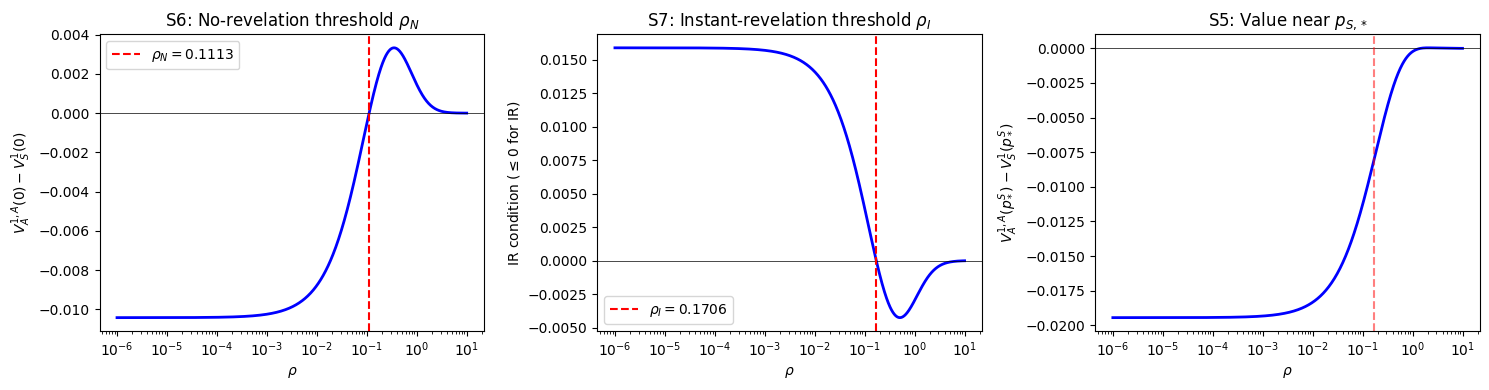

In [ ]:
print("=" * 70)
print("Statements 5-8, 14: Thresholds and equilibrium structure")
print("=" * 70)

# --- Helper: compute V1A(0)-V1S(0) and IR condition for a given rho_val ---
def compute_thresholds(rho_val):
    """Returns (diff_NR, ir_cond) for a single rho_val value."""
    pp_v = solve_ODE_p(F_pp.subs(r, rho_val), X_pp, n_grid_points=N_ODE)
    _1p_v = solve_ODE_p(F_1p.subs(r, rho_val), X_1p, n_grid_points=N_ODE)

    v1s_0 = float(np.real(1 - pp_v[e1][0]))
    v1a_0 = float(np.real(1 - _1p_v[e1A][0]))
    v1b_0 = float(np.real(1 - _1p_v[e1B][0]))
    v0b_0 = float(np.real(v1b_0 - _1p_v[e0B][0]))

    diff_nr = v1a_0 - v1s_0

    a_coef = 3/2
    b_coef = v0b_0 - v1a_0 + rho_val
    c_coef = -rho_val * v1a_0
    disc = b_coef**2 - 4 * a_coef * c_coef
    if disc >= 0:
        e0_I = (-b_coef + np.sqrt(disc)) / (2 * a_coef)
        ir_cond = 0.5 * (1 - v1a_0)**2 + e0_I * v1b_0 - (rho_val + e0_I) * v1a_0
    else:
        ir_cond = np.nan

    return diff_nr, ir_cond, v1a_0, v1s_0, v1b_0, v0b_0, pp_v, _1p_v

# Collect values on the main grid
V1A_at_0 = []
V1S_at_0 = []
V1A_at_pbar = []
V1S_at_pbar = []
IR_condition = []
rho_valid = []

for rho_val in rho_grid:
    if results[rho_val] is None: continue
    pp_v = results[rho_val]['pp']
    _1p_v = results[rho_val]['1p']

    v1s_0 = float(np.real(1 - pp_v[e1][0]))
    v1a_0 = float(np.real(1 - _1p_v[e1A][0]))
    v1b_0 = float(np.real(1 - _1p_v[e1B][0]))
    v0b_0 = float(np.real(v1b_0 - _1p_v[e0B][0]))

    V1S_at_0.append(v1s_0)
    V1A_at_0.append(v1a_0)

    # Evaluate at p*_S (the symmetric critical point, per Lemma D.1)
    p_star_S = float(np.real(pp_v[SS(p)]))
    p_bar = p_star_S - 1e-4

    v1s_interp = interp1d(np.real(pp_v[p]), np.real(1 - pp_v[e1]), kind='cubic', fill_value='extrapolate')
    v1a_interp = interp1d(np.real(_1p_v[pB]), np.real(1 - _1p_v[e1A]), kind='cubic', fill_value='extrapolate')

    V1S_at_pbar.append(float(v1s_interp(p_bar)))
    V1A_at_pbar.append(float(v1a_interp(p_bar)))

    a_coef = 3/2
    b_coef = v0b_0 - v1a_0 + rho_val
    c_coef = -rho_val * v1a_0
    disc = b_coef**2 - 4 * a_coef * c_coef
    if disc >= 0:
        e0_I = (-b_coef + np.sqrt(disc)) / (2 * a_coef)
        ir_val = 0.5 * (1 - v1a_0)**2 + e0_I * v1b_0 - (rho_val + e0_I) * v1a_0
    else:
        ir_val = np.nan
    IR_condition.append(ir_val)
    rho_valid.append(rho_val)

V1A_at_0 = np.array(V1A_at_0, dtype=float)
V1S_at_0 = np.array(V1S_at_0, dtype=float)
V1A_at_pbar = np.array(V1A_at_pbar, dtype=float)
V1S_at_pbar = np.array(V1S_at_pbar, dtype=float)
IR_condition = np.array(IR_condition, dtype=float)
rho_valid = np.array(rho_valid, dtype=float)
diff_NR = V1A_at_0 - V1S_at_0

# --- Refine rho_N using brentq ---
sign_changes = np.where(np.diff(np.sign(diff_NR)))[0]
if len(sign_changes) > 0:
    idx = sign_changes[0]
    lo, hi = rho_valid[idx], rho_valid[idx+1]
    rho_N_approx = brentq(lambda rv: compute_thresholds(rv)[0], lo, hi, xtol=1e-6)
    print(f"\nS6: rho_N (NR threshold) = {rho_N_approx:.6f}  (paper: 0.1113)")
else:
    print(f"\nS6: Could not find rho_N crossing on this grid.")
    rho_N_approx = 0.1113

# --- Refine rho_I using brentq ---
valid_ir = ~np.isnan(IR_condition)
ir_vals = IR_condition[valid_ir]
rho_ir = rho_valid[valid_ir]
sign_changes_IR = np.where(np.diff(np.sign(ir_vals)))[0]
if len(sign_changes_IR) > 0:
    idx = sign_changes_IR[0]
    lo, hi = rho_ir[idx], rho_ir[idx+1]
    rho_I_approx = brentq(lambda rv: compute_thresholds(rv)[1], lo, hi, xtol=1e-6)
    print(f"S7: rho_I (IR threshold) = {rho_I_approx:.6f}  (paper: 0.1706)")
else:
    print(f"S7: Could not find rho_I crossing on this grid.")
    rho_I_approx = 0.1706

# --- S8: Check NR and IR don't coexist ---
print(f"\nS8: rho_N < rho_I? {rho_N_approx:.6f} < {rho_I_approx:.6f} -> {'PASS' if rho_N_approx < rho_I_approx else 'FAIL'}")

# --- S5: V1A(p) < V1S(p) for p in [0, p*_B) when rho_val < rho_I ---
s5_pass = s5_fail = 0
for i, rho_val in enumerate(rho_valid):
    if rho_val < rho_I_approx - 0.01:
        if V1A_at_pbar[i] < V1S_at_pbar[i] + 1e-6:
            s5_pass += 1
        else:
            s5_fail += 1
            print(f"  S5 FAIL at rho_val={rho_val:.4e}: V1A(p*_S)={V1A_at_pbar[i]:.6f} >= V1S(p*_S)={V1S_at_pbar[i]:.6f}")
print(f"\nS5: {s5_pass} PASS, {s5_fail} FAIL (tested for rho < rho_I)")

# --- S14: Three regimes ---
print(f"\nS14: Equilibrium regimes (rho = ar/v):")
print(f"  NR: rho in [0, {rho_N_approx:.4f}]")
print(f"  Mixed: rho in ({rho_N_approx:.4f}, {rho_I_approx:.4f})")
print(f"  IR: rho in [{rho_I_approx:.4f}, inf)")

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(rho_valid, diff_NR, 'b-', linewidth=2)
axes[0].axhline(0, color='k', linewidth=0.5)
axes[0].axvline(rho_N_approx, color='r', linestyle='--', label=f'$\\rho_N={rho_N_approx:.4f}$')
axes[0].set_xlabel('$\\rho$'); axes[0].set_ylabel('$V^{1,A}_A(0) - V^1_S(0)$')
axes[0].set_title('S6: No-revelation threshold $\\rho_N$'); axes[0].legend(); axes[0].set_xscale('log')

axes[1].plot(rho_valid, IR_condition, 'b-', linewidth=2)
axes[1].axhline(0, color='k', linewidth=0.5)
axes[1].axvline(rho_I_approx, color='r', linestyle='--', label=f'$\\rho_I={rho_I_approx:.4f}$')
axes[1].set_xlabel('$\\rho$'); axes[1].set_ylabel('IR condition ($\\leq 0$ for IR)')
axes[1].set_title('S7: Instant-revelation threshold $\\rho_I$'); axes[1].legend(); axes[1].set_xscale('log')

axes[2].plot(rho_valid, V1A_at_pbar - V1S_at_pbar, 'b-', linewidth=2)
axes[2].axhline(0, color='k', linewidth=0.5)
axes[2].axvline(rho_I_approx, color='r', linestyle='--', alpha=0.5)
axes[2].set_xlabel('$\\rho$'); axes[2].set_ylabel('$V^{1,A}_A(p^S_*) - V^1_S(p^S_*)$')
axes[2].set_title('S5: Value near $p_{S,*}$'); axes[2].set_xscale('log')

plt.tight_layout(); plt.show()

---
## Statement S6b: Single-crossing verification

**Paper reference:** Lemma D.2

**S6b:** If $V^{1,A}_A(0) \le V^1_S(0)$, then $V^{1,A}_A(p) \le V^1_S(p)$ for all $p \in [0, p_{S,*})$.

In [ ]:
print("=" * 70)
print("S6b: If V1A(0) <= V1S(0), then V1A(p) <= V1S(p) for all p in [0, p*_S)")
print("     (per Lemma D.2)")
print("=" * 70)

s6b_pass = s6b_fail = 0
for i, rho_val in enumerate(rho_valid):
    if V1A_at_0[i] > V1S_at_0[i] + 1e-8:
        continue
    if results[rho_val] is None: continue
    pp_v = results[rho_val]['pp']
    _1p_v = results[rho_val]['1p']

    p_star_S = float(np.real(pp_v[SS(p)]))
    p_bar = p_star_S - 1e-4
    p_test = np.linspace(0, p_bar, 200)
    v1s_fun = interp1d(np.real(pp_v[p]), np.real(1 - pp_v[e1]), kind='cubic', fill_value='extrapolate')
    v1a_fun = interp1d(np.real(_1p_v[pB]), np.real(1 - _1p_v[e1A]), kind='cubic', fill_value='extrapolate')

    diff = v1a_fun(p_test) - v1s_fun(p_test)
    if np.all(diff < 1e-6):
        s6b_pass += 1
    else:
        s6b_fail += 1
        idx = np.argmax(diff)
        print(f"  S6b FAIL rho_val={rho_val:.4e}: max(V1A-V1S)={diff[idx]:.2e} at p={p_test[idx]:.4f}")

print(f"\nS6b: {s6b_pass} PASS, {s6b_fail} FAIL")

S6b: If V1A(0) <= V1S(0), then V1A(p) <= V1S(p) for all p in [0, p*_S)
     (per Lemma D.2)

S6b: 721 PASS, 0 FAIL


---
## Statement S9: Strategic substitutes

**Paper reference:** Proof of Lemma D.4 (Supplementary Appendix)

**S9:** $V^{1,B}_A(p) - \overline{V}(p) > 0$, where $\overline{V}(p) = V^{1,A}_A(p) + (1-p)(V^{1,A}_A)'(p)$.

This ensures the coefficient on the rival's revelation rate in the postponement benefit is positive, making revelation rates strategic substitutes.

Statement 9: V^{1,B}_A(p) - Vbar(p) > 0 for all p in [0, 1)
  where Vbar(p) = V^{1,A}_A(p) + (1-p)*(V^{1,A}_A)'(p)

Statement 9: 1000 PASS, 0 FAIL


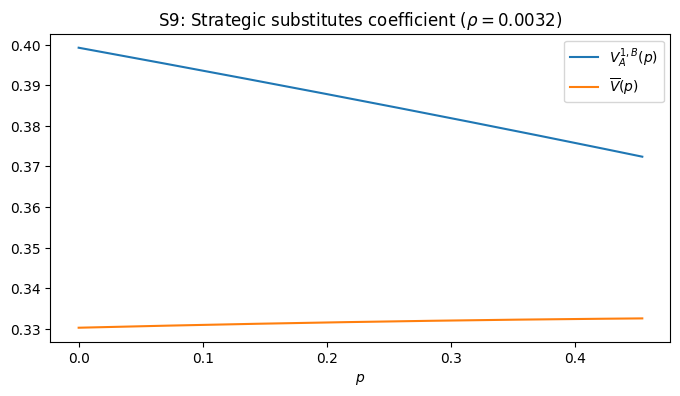

In [ ]:
print("=" * 70)
print("Statement 9: V^{1,B}_A(p) - Vbar(p) > 0 for all p in [0, 1)")
print("  where Vbar(p) = V^{1,A}_A(p) + (1-p)*(V^{1,A}_A)'(p)")
print("=" * 70)

s9_pass = s9_fail = 0
for rho_val in rho_grid:
    if results[rho_val] is None: continue
    v = results[rho_val]['1p']

    v1A_vals = np.real(1 - v[e1A])
    v1B_vals = np.real(1 - v[e1B])
    v1A_prime_vals = np.real(-v[prime(e1A)])
    p_vals = np.real(v[pB])

    Vbar_vals = v1A_vals + (1 - p_vals) * v1A_prime_vals

    diff = v1B_vals - Vbar_vals

    mask = p_vals < float(np.real(v[SS(pB)])) - 1e-4
    if np.all(diff[mask] > -1e-8):
        s9_pass += 1
    else:
        s9_fail += 1
        idx = np.argmin(diff[mask])
        print(f"  S9 FAIL rho_val={rho_val:.4e}: min(V1B-Vbar)={diff[mask][idx]:.2e} at p={p_vals[mask][idx]:.4f}")

print(f"\nStatement 9: {s9_pass} PASS, {s9_fail} FAIL")

# Illustrative plot
rho_plot = rho_grid[len(rho_grid)//2]
if results[rho_plot] is not None:
    v = results[rho_plot]['1p']
    v1B_vals = np.real(1 - v[e1B])
    v1A_vals = np.real(1 - v[e1A])
    p_vals = np.real(v[pB])
    Vbar_vals = v1A_vals + (1 - p_vals) * np.real(-v[prime(e1A)])
    mask = p_vals < float(np.real(v[SS(pB)])) - 0.01

    plt.figure(figsize=(8, 4))
    plt.plot(p_vals[mask], v1B_vals[mask], label='$V^{1,B}_A(p)$')
    plt.plot(p_vals[mask], Vbar_vals[mask], label=r'$\overline{V}(p)$')
    plt.xlabel('$p$'); plt.legend()
    plt.title(f'S9: Strategic substitutes coefficient ($\\rho={rho_plot:.4f}$)')
    plt.show()

---
## Statement S10: Source-type critical point of the mixed ODE system

**Paper reference:** Proof of Lemma D.4(ii) (Supplementary Appendix)

The mixed-revelation ODE system (with $v^1_M = V^{1,A}_A(p)$ imposed) has at most one critical point,
and this critical point is of **source type** (all eigenvalues of the Jacobian have positive real parts).

At a critical point: $\dot{p} = 0 \Rightarrow g_M = e^0_M - p \cdot e^1_M$ and $\dot{v}^0_M = 0$.

In [ ]:
print("=" * 70)
print("Statement 10: Mixed ODE critical point is of source type")
print("=" * 70)

s10_pass = s10_fail = s10_skip = 0

for rho_val in rho_grid:
    if results[rho_val] is None: continue
    _1p_v = results[rho_val]['1p']

    my_interp = lambda X, Y: interp1d(X, Y, kind='cubic', fill_value='extrapolate')
    V1A_fun = my_interp(np.real(_1p_v[pB]), np.real(1 - _1p_v[e1A]))
    V1B_fun = my_interp(np.real(_1p_v[pB]), np.real(1 - _1p_v[e1B]))
    V0B_fun = my_interp(np.real(_1p_v[pB]), np.real(1 - _1p_v[e1B] - _1p_v[e0B]))
    E1A_fun = my_interp(np.real(_1p_v[pB]), np.real(_1p_v[e1A]))
    V1A_prime_fun = my_interp(np.real(_1p_v[pB]), np.real(-_1p_v[prime(e1A)]))

    def crit_eq(p_val):
        p_val = float(np.clip(p_val, 1e-10, 0.999))
        v1a = float(V1A_fun(p_val))
        e1_m = 1 - v1a
        v1b = float(V1B_fun(p_val))
        numer = 0.5 * e1_m**2 - (rho_val + p_val * e1_m) * v1a
        denom = v1a - v1b
        if abs(denom) < 1e-15: return 1e10
        g_from_indiff = numer / denom
        e0_m = g_from_indiff + p_val * e1_m
        v0_m = v1a - e0_m
        v0b = float(V0B_fun(p_val))
        residual = 0.5 * e0_m**2 + g_from_indiff * v0b - (rho_val + e0_m) * v0_m
        return residual

    p_search = np.linspace(0.01, 0.95, 200)
    crit_vals = np.array([crit_eq(pv) for pv in p_search])

    sign_ch = np.where(np.diff(np.sign(crit_vals)))[0]
    n_crit = len(sign_ch)

    if n_crit == 0:
        s10_pass += 1
        continue

    all_source = True
    for idx in sign_ch:
        try:
            p_crit = brentq(crit_eq, p_search[idx], p_search[idx+1])
        except:
            continue

        v1a_c = float(V1A_fun(p_crit))
        e1_c = 1 - v1a_c
        v1b_c = float(V1B_fun(p_crit))
        g_c = (0.5 * e1_c**2 - (rho_val + p_crit * e1_c) * v1a_c) / (v1a_c - v1b_c)
        e0_c = g_c + p_crit * e1_c
        v0_c = v1a_c - e0_c

        eps = 1e-7
        def rhs_2d(v0_val, p_val):
            v1a_v = float(V1A_fun(p_val))
            e1_v = 1 - v1a_v
            e0_v = v1a_v - v0_val
            v1b_v = float(V1B_fun(p_val))
            v0b_v = float(V0B_fun(p_val))
            v1a_p = float(V1A_prime_fun(p_val))
            Vbar_v = v1a_v + (1 - p_val) * v1a_p
            numer_t = 0.5 * e1_v**2 - (rho_val + e0_v) * v1a_v + (e0_v - p_val * e1_v) * Vbar_v
            denom_t = Vbar_v - v1b_v
            if abs(denom_t) < 1e-15: return np.array([0.0, 0.0])
            g_v = numer_t / denom_t
            dv0 = -(0.5 * e0_v**2 + g_v * v0b_v - (rho_val + g_v + p_val * e1_v) * v0_val)
            dp = (1 - p_val) * (e0_v - p_val * e1_v - g_v)
            return np.array([dv0, dp])

        J = np.zeros((2, 2))
        f0 = rhs_2d(v0_c, p_crit)
        fv = rhs_2d(v0_c + eps, p_crit)
        fp = rhs_2d(v0_c, p_crit + eps)
        J[:, 0] = (fv - f0) / eps
        J[:, 1] = (fp - f0) / eps

        eigs = np.linalg.eigvals(J)
        is_source = np.all(np.real(eigs) > 0)

        if not is_source:
            all_source = False
            print(f"  S10 FAIL rho_val={rho_val:.4e}: p_crit={p_crit:.4f}, eigs={eigs}")

    if n_crit <= 1 and all_source:
        s10_pass += 1
    elif n_crit > 1:
        s10_fail += 1
        print(f"  S10 FAIL rho_val={rho_val:.4e}: found {n_crit} critical points (expect at most 1)")
    elif not all_source:
        s10_fail += 1

print(f"\nStatement 10: {s10_pass} PASS, {s10_fail} FAIL")

Statement 10: Mixed ODE critical point is of source type

Statement 10: 1000 PASS, 0 FAIL


---
## Statements S11, S12, S13, S15, S16: Mixed-equilibrium properties

These require solving the mixed equilibrium for $\rho \in (\rho_N, \rho_I)$.

**Paper references:**
- **S11** (Proposition 11): $G_M(p)$ is strictly decreasing in $p$ for $p \in [0, \overline{p}_M]$.
- **S12** (Lemma D.3): Unique crossing point $\overline{p}_M \in (0, p_{S,*})$ where $V^{1,A}_A(\overline{p}) = V^1_S(\overline{p})$.
- **S13** (Proposition 12): When IR exists, $G_M(0) \ge E^0_M(0)$ (mixed eq doesn't exist).
- **S15** (Discussion after Proposition 12): Deadline $T$ increases with $\rho$.
- **S16** (Discussion after Proposition 12): Probability of revelation before patent is strictly increasing in $\rho$.

Statements 11-13, 15-16: Mixed-equilibrium properties
Mixed regime: rho in (0.1113, 0.1706)
Dedicated grid: 1000 points, rho from 0.1123 to 0.1696
  200/1000 done
  400/1000 done
  600/1000 done
  800/1000 done
  1000/1000 done

S11: 1000 PASS, 0 FAIL  (G_M decreasing in p)
S12: 1000 PASS, 0 FAIL  (unique crossing pbar_M)

--- S13: IR regime -> mixed eq doesn't exist ---
S13: 5 PASS, 0 FAIL

--- S15: Deadline T increases with rho_val ---
S15: PASS: T monotonically increasing (0.02 to 4.61)

--- S16: Prob(revelation) increases with rho_val ---
S16: PASS: prob monotonically increasing (0.0101 to 0.9419)


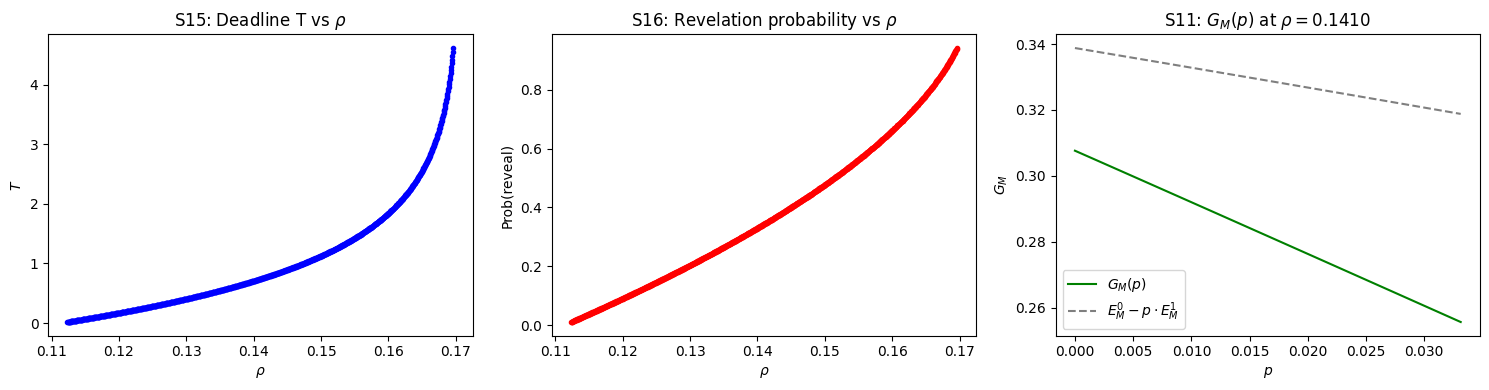

In [ ]:
print("=" * 70)
print("Statements 11-13, 15-16: Mixed-equilibrium properties")
print("=" * 70)

# Dedicated grid between rho_N and rho_I for mixed-equilibrium statements
N_MIXED = N_GRID
mixed_rhos = np.linspace(rho_N_approx + 0.001, rho_I_approx - 0.001, N_MIXED)
print(f"Mixed regime: rho in ({rho_N_approx:.4f}, {rho_I_approx:.4f})")
print(f"Dedicated grid: {N_MIXED} points, rho from {mixed_rhos[0]:.4f} to {mixed_rhos[-1]:.4f}")

s11_pass = s11_fail = 0
s12_pass = s12_fail = 0
T_values = []
prob_values = []
mixed_rho_solved = []

for i, rho_val in enumerate(mixed_rhos):
    try:
        mx = solve_mixed(rho_val)
    except Exception as ex:
        print(f"  solve_mixed FAILED at rho_val={rho_val:.4e}: {ex}")
        continue

    mixed_rho_solved.append(rho_val)
    T_values.append(mx['T'])
    prob_values.append(mx['prob_ever_reveal'])

    # S11: G_M(p) = thetaM is strictly decreasing in p
    p_arr = mx['p_vals']
    theta_arr = mx['thetaM_vals']
    sort_idx = np.argsort(p_arr)
    p_sorted = p_arr[sort_idx]
    theta_sorted = theta_arr[sort_idx]
    dtheta = np.diff(theta_sorted)
    dp = np.diff(p_sorted)
    valid = dp > 1e-12
    if np.sum(valid) > 0 and np.all(dtheta[valid] < 1e-8):
        s11_pass += 1
    else:
        s11_fail += 1
        if np.sum(valid) > 0:
            worst = np.max(dtheta[valid])
            print(f"  S11 FAIL rho_val={rho_val:.4e}: max d(theta)/dp ~ {worst:.2e}")

    # S12: Unique crossing point pbar_M in (0, p*_B)  [p*_B < p*_S by Prop 7]
    pp_v = mx['vals_pp']
    _1p_v = mx['vals_1p']
    v1s_fun = interp1d(np.real(pp_v[p]), np.real(1 - pp_v[e1]), kind='cubic', fill_value='extrapolate')
    v1a_fun = interp1d(np.real(_1p_v[pB]), np.real(1 - _1p_v[e1A]), kind='cubic', fill_value='extrapolate')
    p_star_B = float(np.real(_1p_v[SS(pB)]))
    p_bar_12 = p_star_B - 1e-4
    p_test_12 = np.linspace(1e-4, p_bar_12, 500)
    diff_12 = v1a_fun(p_test_12) - v1s_fun(p_test_12)
    crossings_12 = np.where(np.diff(np.sign(diff_12)))[0]

    if len(crossings_12) == 1:
        s12_pass += 1
    else:
        s12_fail += 1
        print(f"  S12 FAIL rho_val={rho_val:.4e}: found {len(crossings_12)} crossings (expect 1)")

    if (i + 1) % max(1, N_MIXED // 5) == 0:
        print(f"  {i+1}/{N_MIXED} done")

T_values = np.array(T_values)
prob_values = np.array(prob_values)
mixed_rho_solved = np.array(mixed_rho_solved)

print(f"\nS11: {s11_pass} PASS, {s11_fail} FAIL  (G_M decreasing in p)")
print(f"S12: {s12_pass} PASS, {s12_fail} FAIL  (unique crossing pbar_M)")

# S13: When IR exists, G_M(0) >= E0_M(0)
print("\n--- S13: IR regime -> mixed eq doesn't exist ---")
ir_rhos = rho_grid[rho_grid >= rho_I_approx + 0.01]
s13_pass = s13_fail = 0
for rho_val in ir_rhos[:5]:
    try:
        mx_ir = solve_mixed(rho_val)
        idx_0 = np.argmin(np.abs(mx_ir['p_vals']))
        g_at_0 = mx_ir['thetaM_vals'][idx_0]
        ub_at_0 = mx_ir['thetaM_UB'][idx_0]
        if g_at_0 >= ub_at_0 - 1e-6:
            s13_pass += 1
        else:
            s13_fail += 1
            print(f"  S13 FAIL rho_val={rho_val:.4e}: G_M(0)={g_at_0:.4f}, UB={ub_at_0:.4f}")
    except Exception as exc:
        s13_pass += 1  # solver failure = mixed eq doesn't exist

print(f"S13: {s13_pass} PASS, {s13_fail} FAIL")

# S15: T increases with rho_val
s15_pass = s15_fail = 0
print("\n--- S15: Deadline T increases with rho_val ---")
if len(T_values) > 1:
    dT = np.diff(T_values)
    drho = np.diff(mixed_rho_solved)
    mask_pos = drho > 0
    if np.all(dT[mask_pos] > -1e-8):
        s15_pass = 1
        print(f"S15: PASS: T monotonically increasing ({T_values[0]:.2f} to {T_values[-1]:.2f})")
    else:
        s15_fail = 1
        bad = np.where(dT < -1e-8)[0]
        print(f"S15: FAIL: T decreases at {len(bad)} points")
        for b in bad[:3]:
            print(f"  rho_val={mixed_rho_solved[b]:.4f}: T={T_values[b]:.4f} -> {T_values[b+1]:.4f}")
else:
    print("S15: SKIP: not enough points")

# S16: Probability of revelation increasing in rho_val
s16_pass = s16_fail = 0
print("\n--- S16: Prob(revelation) increases with rho_val ---")
if len(prob_values) > 1:
    dprob = np.diff(prob_values)
    if np.all(dprob[mask_pos] > -1e-8):
        s16_pass = 1
        print(f"S16: PASS: prob monotonically increasing ({prob_values[0]:.4f} to {prob_values[-1]:.4f})")
    else:
        s16_fail = 1
        bad = np.where(dprob < -1e-8)[0]
        print(f"S16: FAIL: prob decreases at {len(bad)} points")
        for b in bad[:3]:
            print(f"  rho_val={mixed_rho_solved[b]:.4f}: prob={prob_values[b]:.4f} -> {prob_values[b+1]:.4f}")
else:
    print("S16: SKIP: not enough points")

# Plots
if len(mixed_rho_solved) > 1:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(mixed_rho_solved, T_values, 'b.-')
    axes[0].set_xlabel('$\\rho$'); axes[0].set_ylabel('$T$')
    axes[0].set_title('S15: Deadline T vs $\\rho$')

    axes[1].plot(mixed_rho_solved, prob_values, 'r.-')
    axes[1].set_xlabel('$\\rho$'); axes[1].set_ylabel('Prob(reveal)')
    axes[1].set_title('S16: Revelation probability vs $\\rho$')

    rho_mid = mixed_rho_solved[len(mixed_rho_solved)//2]
    mx_mid = solve_mixed(rho_mid)
    sort_idx = np.argsort(mx_mid['p_vals'])
    axes[2].plot(mx_mid['p_vals'][sort_idx], mx_mid['thetaM_vals'][sort_idx], 'g-', label='$G_M(p)$')
    axes[2].plot(mx_mid['p_vals'][sort_idx], mx_mid['thetaM_UB'][sort_idx], 'k--', alpha=0.5, label='$E^0_M - p \\cdot E^1_M$')
    axes[2].set_xlabel('$p$'); axes[2].set_ylabel('$G_M$')
    axes[2].set_title(f'S11: $G_M(p)$ at $\\rho={rho_mid:.4f}$')
    axes[2].legend()

    plt.tight_layout(); plt.show()

---
## Summary: Consolidated PASS/FAIL Table

Run the cell below to print a consolidated report of all 16 numerical verification results.

In [ ]:
print("=" * 70)
print("  SUMMARY: Numerical Verification Results")
print(f"  Grid: N_GRID={N_GRID}, rho in [{RHO_MIN}, {RHO_MAX}]")
print(f"  Mixed grid: {N_MIXED} points, rho in ({rho_N_approx:.4f}, {rho_I_approx:.4f})")
print("=" * 70)

results_table = [
    ("S1",  "E^{0,B}_A decreasing in p",            s1_pass,  s1_fail),
    ("S2",  "E^{0,B}_A < E^{1,B}_A (jump up)",      s2_pass,  s2_fail),
    ("S3",  "E^{0,B}_A < E^0_S (discourages)",       s3_pass,  s3_fail),
    ("S4",  "E^{1,B}_A > E^1_S (encourages)",        s4_pass,  s4_fail),
    ("S5",  "V^{1,A}_A(p*) < V^1_S(p*) for rho<rho_I",  s5_pass,  s5_fail),
    ("S6",  f"rho_N = {rho_N_approx:.6f} (paper: $\\rho_N \\approx$ 0.1113)", "---", "---"),
    ("S6b", "Single crossing holds for all p",        s6b_pass, s6b_fail),
    ("S7",  f"rho_I = {rho_I_approx:.6f} (paper: $\\rho_I \\approx$ 0.1706)", "---", "---"),
    ("S8",  f"rho_N < rho_I: {'YES' if rho_N_approx < rho_I_approx else 'NO'}", "---", "---"),
    ("S9",  "V^{1,B}_A - Vbar > 0 (strat. subs.)",  s9_pass,  s9_fail),
    ("S10", "Mixed ODE crit. pt. is source type",    s10_pass, s10_fail),
    ("S11", "G_M(p) strictly decreasing",            s11_pass, s11_fail),
    ("S12", "Unique crossing pbar_M",                s12_pass, s12_fail),
    ("S13", "G_M(0) >= UB when IR exists",           s13_pass, s13_fail),
    ("S14", f"Three regimes: NR/Mixed/IR", "---", "---"),
    ("S15", "T increases with rho",                 s15_pass, s15_fail),
    ("S16", "Prob(reveal) increases with rho",      s16_pass, s16_fail),
]

any_fail = False
for row in results_table:
    label, desc, p, f = row
    if isinstance(p, int):
        status = "PASS" if f == 0 else "!! FAIL !!"
        if f > 0: any_fail = True
        print(f"  {label:5s}  {status:10s}  ({p} pass, {f} fail)  {desc}")
    else:
        print(f"  {label:5s}  {'---':10s}  {desc}")

print("=" * 70)
if any_fail:
    print("  !! SOME STATEMENTS FAILED: see details above.")
else:
    print("  ALL STATEMENTS PASSED.")
print("=" * 70)

print("\n--- Assumptions made (please verify) ---")
print("""
1. Normalization: v=1, a=1, so rho = r (single parameter).
2. ODE solutions use backward integration from the critical point (steady state)
   along the unique stable eigenvector, as in Revealing_in_Patent_Race.ipynb.
3. Tolerance for inequality checks: 1e-6 to 1e-8 (allowing small numerical error).
4. For S3/S4, comparison is on common belief domain [0, min(p*_S, p*_B)).
5. For S5, test restricted to rho < rho_I - 0.01 (margin to avoid near-boundary issues).
6. For S6/S7, thresholds refined using brentq (bisection) to 1e-6 precision.
7. For S7 (IR condition), e0_I is the positive root of the quadratic:
   (3/2)e^2 + (V0B(0) - V1A(0) + r)e - r*V1A(0) = 0.
8. For S10, Jacobian is computed via finite differences (eps=1e-7).
9. For S11, G_M(p) = thetaM(p) from the mixed equilibrium ODE solution.
10. For S13, "mixed eq doesn't exist" is checked by thetaM(0) >= UB = e0M(0) - 0*e1A.
11. Mixed equilibrium solved on dedicated grid in (rho_N, rho_I).
12. For S15/S16, monotonicity is checked by finite differences on the discrete grid.
""")

  SUMMARY: Numerical Verification Results
  Grid: N_GRID=1000, rho in [1e-06, 10.0]
  Mixed grid: 1000 points, rho in (0.1113, 0.1706)
  S1     PASS        (1000 pass, 0 fail)  E^{0,B}_A decreasing in p
  S2     PASS        (1000 pass, 0 fail)  E^{0,B}_A < E^{1,B}_A (jump up)
  S3     PASS        (1000 pass, 0 fail)  E^{0,B}_A < E^0_S (discourages)
  S4     PASS        (1000 pass, 0 fail)  E^{1,B}_A > E^1_S (encourages)
  S5     PASS        (743 pass, 0 fail)  V^{1,A}_A(p*) < V^1_S(p*) for rho<rho_I
  S6     ---         rho_N = 0.111348 (paper: $\rho_N \approx$ 0.1113)
  S6b    PASS        (721 pass, 0 fail)  Single crossing holds for all p
  S7     ---         rho_I = 0.170608 (paper: $\rho_I \approx$ 0.1706)
  S8     ---         rho_N < rho_I: YES
  S9     PASS        (1000 pass, 0 fail)  V^{1,B}_A - Vbar > 0 (strat. subs.)
  S10    PASS        (1000 pass, 0 fail)  Mixed ODE crit. pt. is source type
  S11    PASS        (1000 pass, 0 fail)  G_M(p) strictly decreasing
  S12    PASS   